# Red neuronal convolucional para reconocer el tipo de un Pokémon

En esta tarea se diseña, entrena y evalúa un modelo de red neuronal de arquitectura
**convolucional** para reconocer el **tipo primario** (`Type1`) de un Pokémon a partir de
**su imagen** y de **sus atributos numéricos** (alto, peso, HP, ataque, defensa, velocidad).

El principal desafío es doble:

* **Pocos datos:** sólo ~595 imágenes para **17 clases efectivas**.
* **Fuerte desbalance:** la clase mayoritaria (*Water*) tiene ~96 ejemplos y varias
  minoritarias (*Fairy*, *Dragon*, *Steel*) tienen menos de 20.

La estrategia para enfrentarlo, desarrollada a lo largo del notebook, consiste en:

1. Un modelo **multi-rama** (CNN para la imagen + MLP para los atributos) deliberadamente
   **pequeño** para limitar el sobreajuste.
2. **Normalización** de los atributos y **regularización** (BatchNorm, Dropout, weight decay).
3. **Ponderación de clases** en la función de pérdida para compensar el desbalance.
4. **Early stopping** sobre un conjunto de validación separado.
5. **Aumentación aleatoria de datos** para ampliar artificialmente el conjunto de entrenamiento.

A lo largo del informe se reportan, además de la *accuracy*, la **balanced accuracy** y el
**F1 macro**, que son métricas más informativas bajo desbalance.

In [7]:
# Configuración general, importaciones y reproducibilidad
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             balanced_accuracy_score, f1_score, ConfusionMatrixDisplay)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)
print("Versión de torch:", torch.__version__)

Dispositivo: cuda
Versión de torch: 2.5.1+cu121


## 1. Carga del dataset y exploración

Se instancia el dataset entregado y se muestran algunos ejemplos.

N° de ejemplos: 595
N° de categorías (Type1): 18


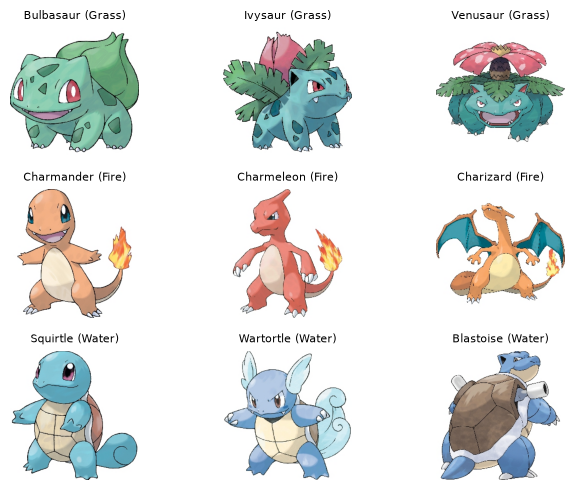

In [8]:
from pokemon_utils import PokemonImages

dataset = PokemonImages('data/')
n_classes = len(dataset.categories)
print(f"N° de ejemplos: {len(dataset)}")
print(f"N° de categorías (Type1): {n_classes}")

fig, ax = plt.subplots(3, 3, figsize=(7, 5), tight_layout=True)
for ax_, (image, label, name, attributes) in zip(ax.ravel(), dataset):
    ax_.imshow(image.permute(-2, -1, 0))
    ax_.set_title(f"{name} ({dataset.categories[label]})", fontsize=8)
    ax_.axis('off')
plt.show()

Cada ejemplo está compuesto por su **imagen**, su **etiqueta** (índice de clase),
su **nombre** y un vector de **atributos**:

In [9]:
image, label, name, attributes = dataset[0]
print("Tipo de imagen:", type(image).__name__, "| shape:", tuple(image.shape))
print("Etiqueta:", label, "->", dataset.categories[label])
print("Nombre:", name)
print("Atributos:", dataset.attribute_names)
print("Valores:  ", attributes.tolist())

Tipo de imagen: Tensor | shape: (3, 256, 256)
Etiqueta: 9 -> Grass
Nombre: Bulbasaur
Atributos: ['Height', 'Weight', 'HP', 'Attack', 'Defense', 'Speed']
Valores:   [0.699999988079071, 6.900000095367432, 45.0, 49.0, 49.0, 45.0]


Todas las imágenes son **RGB de 256×256** y los atributos disponibles son seis.
Veamos la **distribución de clases**, que es clave para entender el problema.

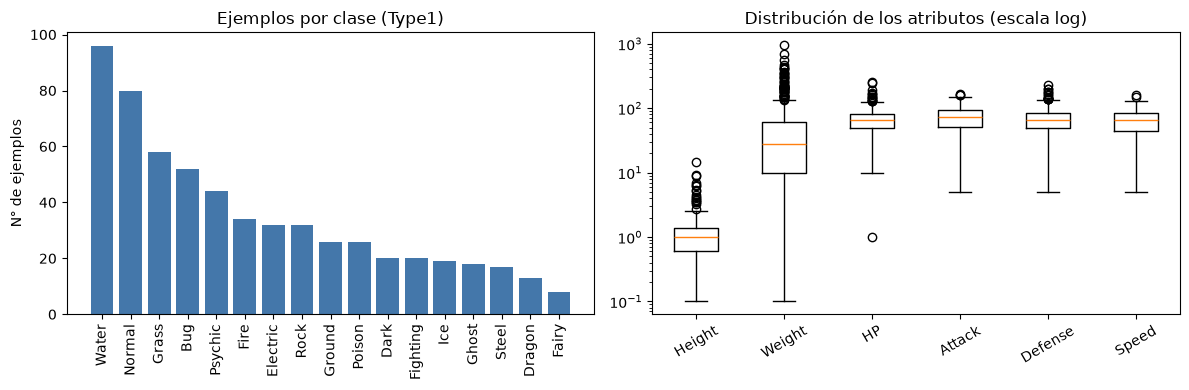

Clases sin ejemplos en este subconjunto: ['Flying']

Resumen de atributos:
       Height  Weight      HP  Attack  Defense   Speed
count  595.00  595.00  595.00  595.00   595.00  595.00
mean     1.13   53.66   67.49   73.66    70.01   64.66
std      1.05   84.43   26.37   28.74    29.51   27.05
min      0.10    0.10    1.00    5.00     5.00    5.00
25%      0.60    9.95   50.00   51.50    50.00   45.00
50%      1.00   28.00   65.00   72.00    65.00   65.00
75%      1.40   60.00   80.00   92.50    85.00   85.00
max     14.50  950.00  255.00  165.00   230.00  160.00


In [10]:
counts = Counter(dataset.labels)
present = [c for c in range(n_classes) if counts.get(c, 0) > 0]
order = sorted(present, key=lambda c: counts[c], reverse=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), tight_layout=True)
axes[0].bar([dataset.categories[c] for c in order], [counts[c] for c in order], color="#4477AA")
axes[0].set_title("Ejemplos por clase (Type1)")
axes[0].set_ylabel("N° de ejemplos")
axes[0].tick_params(axis='x', rotation=90)

# Estadísticas de los atributos (escalas muy distintas -> requieren normalización)
attrs_all = torch.stack([a for *_, a in dataset]).numpy()
attr_df = pd.DataFrame(attrs_all, columns=dataset.attribute_names)
axes[1].boxplot([attr_df[c] for c in dataset.attribute_names], tick_labels=dataset.attribute_names)
axes[1].set_yscale('log')
axes[1].set_title("Distribución de los atributos (escala log)")
axes[1].tick_params(axis='x', rotation=30)
plt.show()

print("Clases sin ejemplos en este subconjunto:",
      [dataset.categories[c] for c in range(n_classes) if counts.get(c, 0) == 0])
print("\nResumen de atributos:")
print(attr_df.describe().round(2))

**Observaciones clave de la exploración:**

* El dataset está **fuertemente desbalanceado** (de ~96 ejemplos en *Water* a ~8 en *Fairy*).
* La clase **`Flying` no tiene ningún ejemplo** entre las imágenes disponibles (ningún Pokémon
  de la pokédex con imagen tiene *Flying* como tipo primario), por lo que trabajamos con
  **17 clases efectivas** aunque la capa de salida tenga 18 neuronas.
* Los atributos tienen **escalas muy diferentes** (el peso llega a ~950 y el alto a ~14):
  esto obliga a **estandarizarlos** antes de entrenar.

## 2. Conjuntos de entrenamiento y prueba

Se utiliza la partición entregada (15 % de prueba, estratificada). Este conjunto de **prueba
se reserva exclusivamente para la evaluación final** y no se usa para ajustar el modelo.

In [11]:
from torch.utils.data import Subset

train_idx, test_idx = train_test_split(
    np.arange(len(dataset)), test_size=0.15, random_state=1234,
    shuffle=True, stratify=dataset.labels)

train_dataset = Subset(dataset, train_idx)
test_dataset = Subset(dataset, test_idx)
print(f"Entrenamiento (train): {len(train_idx)} ejemplos")
print(f"Prueba (test):         {len(test_idx)} ejemplos")

Entrenamiento (train): 505 ejemplos
Prueba (test):         90 ejemplos


## 3. Definición del modelo

**Justificación de las decisiones de diseño.**

El problema combina dos fuentes de información de naturaleza distinta, por lo que se diseña un
modelo **multi-rama** que las procesa por separado y luego las fusiona:

* **Rama de imagen (CNN).** Cuatro bloques convolucionales `Conv→BatchNorm→ReLU→MaxPool`. Se
  usa una CNN porque explota la estructura espacial de la imagen con pocos parámetros (pesos
  compartidos). Se mantiene **pequeña** (32→64→128→128 canales) porque con sólo ~400 imágenes de
  entrenamiento una red grande se sobreajustaría de inmediato. Un `AdaptiveAvgPool` final resume
  cada mapa de características en un vector, reduciendo drásticamente el número de parámetros del
  clasificador (alternativa más robusta que aplanar).
* **Rama de atributos (MLP).** Un perceptrón pequeño que proyecta los 6 atributos estandarizados
  a un espacio de 32 dimensiones.
* **Fusión y clasificador.** Se concatenan ambos vectores y un MLP final produce los 18 logits.

**Regularización** (esencial con tan pocos datos): `BatchNorm` en cada bloque, `Dropout` en las
capas densas y `weight_decay` en el optimizador.

**Decisiones del pipeline de datos:**

* Las imágenes se **reescalan a 64×64**: suficiente para distinguir color/forma y mucho más
  liviano de entrenar en CPU que 256×256.
* Los **atributos se estandarizan** (z-score) usando únicamente estadísticas del conjunto de
  entrenamiento, para no filtrar información de validación/prueba.
* Para validar y aplicar *early stopping* sin tocar el test, se separa un **15 % del train como
  conjunto de validación** (estratificado).

In [12]:
# --- Separación de un conjunto de validación a partir del train (estratificado) ---
train_labels = [dataset.labels[i] for i in train_idx]
tr_idx, val_idx = train_test_split(
    train_idx, test_size=0.1765, shuffle=True, stratify=train_labels)
print(f"train final: {len(tr_idx)} | validación: {len(val_idx)} | test: {len(test_idx)}")

# --- Estandarización de atributos con estadísticas SOLO del train ---
tr_attrs = torch.stack([dataset[i][3] for i in tr_idx])
attr_mean = tr_attrs.mean(0)
attr_std = tr_attrs.std(0) + 1e-6
print("Media atributos :", attr_mean.round(decimals=2).tolist())
print("Desv. atributos :", attr_std.round(decimals=2).tolist())

# --- Transformaciones de imagen ---
IMG = 256
eval_tf = v2.Compose([
    v2.Resize(IMG),
])

# --- Dataset envoltorio: aplica transformación de imagen + estandariza atributos ---
class WrappedPokemon(Dataset):
    def __init__(self, indices, transform):
        self.indices = list(indices)
        self.transform = transform
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, i):
        image, label, name, attrs = dataset[self.indices[i]]
        image = self.transform(image)
        attrs = (attrs - attr_mean) / attr_std
        return image, attrs, label

train final: 415 | validación: 90 | test: 90
Media atributos : [1.1399999856948853, 53.68000030517578, 68.2699966430664, 74.48999786376953, 68.33999633789062, 66.4800033569336]
Desv. atributos : [1.059999942779541, 83.87000274658203, 27.739999771118164, 29.40999984741211, 28.040000915527344, 27.68000030517578]


In [13]:
# --- Definición de la arquitectura ---
import torch
import torch.nn as nn

class PokemonNet(nn.Module):
    def __init__(self, n_classes=17, n_attrs=6, p_drop=0.4):
        super().__init__()

        def conv_block(c_in, c_out):
            return nn.Sequential(
                nn.Conv2d(c_in, c_out, 3, padding=1, bias=False),
                nn.BatchNorm2d(c_out),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2)
            )

        self.cnn = nn.Sequential(
            conv_block(3, 32),
            conv_block(32, 64),
            conv_block(64, 128),
            conv_block(128, 256)
        )

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.flatten = nn.Flatten()

        self.img_head = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p_drop)
        )

        self.attr_head = nn.Sequential(
            nn.Linear(n_attrs, 32),
            nn.ReLU(inplace=True),
            nn.Linear(32, 32),
            nn.ReLU(inplace=True)
        )

        self.classifier = nn.Sequential(
            nn.Linear(128 + 32, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p_drop),

            nn.Linear(128, 64),
            nn.ReLU(inplace=True),

            nn.Linear(64, 32),
            nn.ReLU(inplace=True),

            nn.Linear(32, n_classes)
        )

    def forward(self, image, attrs):
        x_img = self.flatten(self.pool(self.cnn(image)))  # ← ahora 256
        x_img = self.img_head(x_img)

        x_attr = self.attr_head(attrs)

        x = torch.cat([x_img, x_attr], dim=1)
        return self.classifier(x)

model = PokemonNet(n_classes).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nN° de parámetros entrenables: {n_params:,}")

PokemonNet(
  (cnn): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
   

## 4. Entrenamiento del modelo

**Elección de hiperparámetros (justificación):**

* **Pérdida `CrossEntropyLoss` ponderada por clase.** El peso de cada clase es inversamente
  proporcional a su frecuencia, de modo que los errores en clases minoritarias pesan más. Es la
  herramienta central contra el desbalance.
* **Optimizador Adam** (`lr=1e-3`, `weight_decay=1e-4`): convergencia rápida y estable; el
  *weight decay* añade regularización L2.
* **Tamaño de lote 32**, equilibrio entre ruido del gradiente y velocidad en CPU.
* **`ReduceLROnPlateau`**: baja la tasa de aprendizaje cuando la pérdida de validación se estanca.
* **Early stopping** (paciencia 15) restaurando los pesos de la mejor época según la pérdida de
  validación, para evitar el sobreajuste.

Se reservan estos hiperparámetros y se grafican las **curvas de aprendizaje**.

In [14]:
# --- Pesos de clase (inversamente proporcionales a la frecuencia) ---
tr_counts = Counter([dataset.labels[i] for i in tr_idx])
class_weights = torch.tensor(
    [len(tr_idx) / (n_classes * tr_counts[c]) if tr_counts.get(c, 0) > 0 else 0.0
     for c in range(n_classes)], dtype=torch.float32, device=device)

BATCH = 32

def make_loader(indices, transform, shuffle):
    return DataLoader(WrappedPokemon(indices, transform), batch_size=BATCH if shuffle else 64,
                      shuffle=shuffle, num_workers=0)

def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    total, loss_sum, correct = 0, 0.0, 0
    for image, attrs, y in loader:
        image, attrs, y = image.to(device), attrs.to(device), y.to(device)
        with torch.set_grad_enabled(is_train):
            out = model(image, attrs)
            loss = criterion(out, y)
            if is_train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
        bs = y.size(0)
        loss_sum += loss.item() * bs; total += bs
        correct += (out.argmax(1) == y).sum().item()
    return loss_sum / total, correct / total

def train_model(train_transform, epochs=60, patience=15, verbose=True):
    model = PokemonNet(n_classes).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=5)
    train_loader = make_loader(tr_idx, train_transform, shuffle=True)
    val_loader = make_loader(val_idx, eval_tf, shuffle=False)

    history = {k: [] for k in ['train_loss', 'val_loss', 'train_acc', 'val_acc']}
    best_val, best_state, bad = float('inf'), None, 0
    for ep in range(1, epochs + 1):
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, criterion)
        scheduler.step(val_loss)
        history['train_loss'].append(tr_loss); history['val_loss'].append(val_loss)
        history['train_acc'].append(tr_acc);   history['val_acc'].append(val_acc)
        if val_loss < best_val - 1e-4:
            best_val, best_state, bad = val_loss, {k: v.detach().clone() for k, v in model.state_dict().items()}, 0
        else:
            bad += 1
        if verbose and (ep % 5 == 0 or ep == 1):
            print(f"Época {ep:3d} | train loss {tr_loss:.3f} acc {tr_acc:.3f} "
                  f"| val loss {val_loss:.3f} acc {val_acc:.3f}")
        if bad >= patience:
            if verbose: print(f"Early stopping en la época {ep} (mejor val loss {best_val:.3f}).")
            break
    model.load_state_dict(best_state)
    return model, history

Época   1 | train loss 2.899 acc 0.070 | val loss 2.892 acc 0.067
Época   5 | train loss 2.746 acc 0.111 | val loss 2.759 acc 0.089
Época  10 | train loss 2.545 acc 0.198 | val loss 2.768 acc 0.133
Época  15 | train loss 2.343 acc 0.193 | val loss 2.382 acc 0.189
Época  20 | train loss 2.131 acc 0.301 | val loss 2.370 acc 0.222
Época  25 | train loss 2.041 acc 0.287 | val loss 2.431 acc 0.278
Época  30 | train loss 1.982 acc 0.330 | val loss 2.454 acc 0.233
Época  35 | train loss 1.852 acc 0.320 | val loss 2.562 acc 0.189
Época  40 | train loss 1.756 acc 0.323 | val loss 2.453 acc 0.200
Época  45 | train loss 1.713 acc 0.340 | val loss 2.353 acc 0.200
Época  50 | train loss 1.682 acc 0.398 | val loss 2.509 acc 0.244
Early stopping en la época 52 (mejor val loss 2.270).


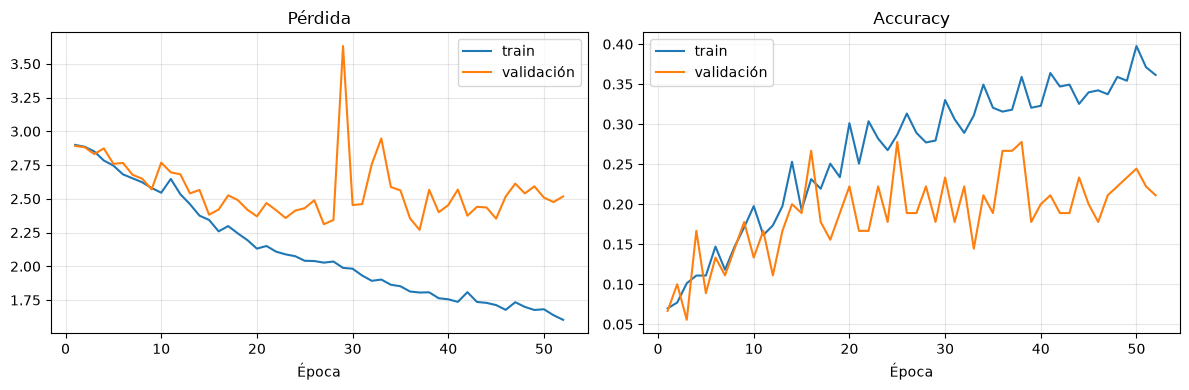

In [15]:
# --- Entrenamiento del modelo base (SIN aumentación) ---
base_model, base_history = train_model(eval_tf, epochs=60, patience=15)

# --- Curvas de aprendizaje ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4), tight_layout=True)
ep = range(1, len(base_history['train_loss']) + 1)
axes[0].plot(ep, base_history['train_loss'], label='train')
axes[0].plot(ep, base_history['val_loss'], label='validación')
axes[0].set_title('Pérdida'); axes[0].set_xlabel('Época'); axes[0].legend(); axes[0].grid(alpha=.3)
axes[1].plot(ep, base_history['train_acc'], label='train')
axes[1].plot(ep, base_history['val_acc'], label='validación')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Época'); axes[1].legend(); axes[1].grid(alpha=.3)
plt.show()

## 5. Evaluación del modelo

Se evalúa el modelo base en el **conjunto de prueba** reservado, usando la **matriz de
confusión** y el **reporte de clasificación**. Dado el desbalance, además de la *accuracy* se
reportan la **balanced accuracy** (promedio del *recall* por clase) y el **F1 macro**.

In [16]:
@torch.no_grad()
def predict(model, indices):
    # Devuelve (y_true, y_pred) preservando el orden de 'indices'.
    model.eval()
    loader = make_loader(indices, eval_tf, shuffle=False)
    ys, ps = [], []
    for image, attrs, y in loader:
        out = model(image.to(device), attrs.to(device))
        ps.append(out.argmax(1).cpu()); ys.append(y)
    return torch.cat(ys).numpy(), torch.cat(ps).numpy()

def report_metrics(y_true, y_pred, title=""):
    acc = (y_true == y_pred).mean()
    bal = balanced_accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average='macro', zero_division=0)
    print(f"{title}")
    print(f"  Accuracy          : {acc:.3f}")
    print(f"  Balanced accuracy : {bal:.3f}")
    print(f"  F1 macro          : {f1m:.3f}")
    return dict(accuracy=acc, balanced_accuracy=bal, f1_macro=f1m)

y_true, y_pred = predict(base_model, test_idx)
base_metrics = report_metrics(y_true, y_pred, "Modelo base (sin aumentación) — conjunto de prueba")

Modelo base (sin aumentación) — conjunto de prueba
  Accuracy          : 0.333
  Balanced accuracy : 0.321
  F1 macro          : 0.263


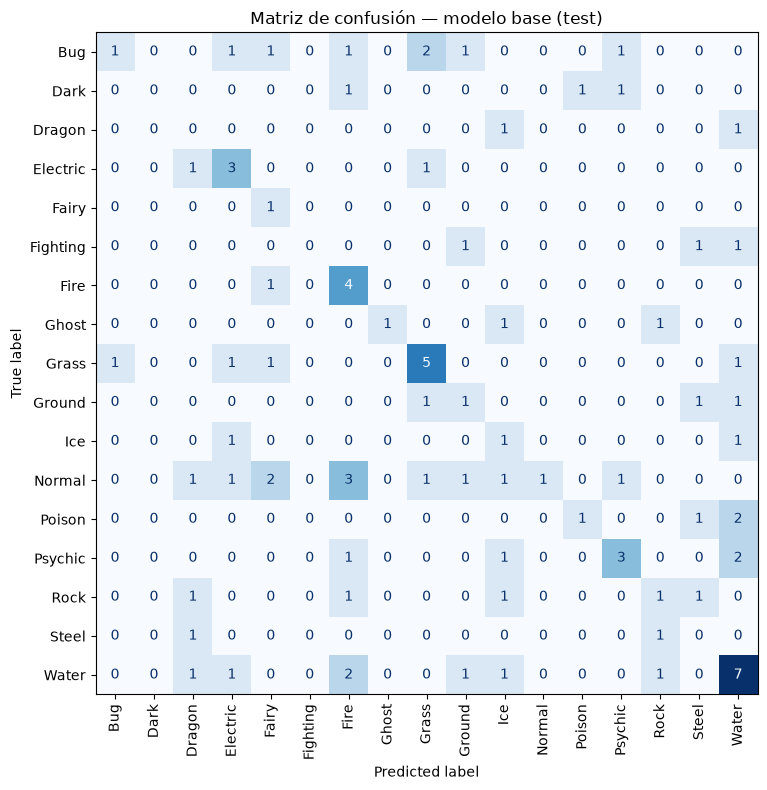

              precision    recall  f1-score   support

         Bug       0.50      0.12      0.20         8
        Dark       0.00      0.00      0.00         3
      Dragon       0.00      0.00      0.00         2
    Electric       0.38      0.60      0.46         5
       Fairy       0.17      1.00      0.29         1
    Fighting       0.00      0.00      0.00         3
        Fire       0.31      0.80      0.44         5
       Ghost       1.00      0.33      0.50         3
       Grass       0.50      0.56      0.53         9
      Ground       0.20      0.25      0.22         4
         Ice       0.14      0.33      0.20         3
      Normal       1.00      0.08      0.15        12
      Poison       0.50      0.25      0.33         4
     Psychic       0.50      0.43      0.46         7
        Rock       0.25      0.20      0.22         5
       Steel       0.00      0.00      0.00         2
       Water       0.44      0.50      0.47        14

    accuracy              

In [17]:
# --- Matriz de confusión (sólo clases presentes) ---
labels_present = sorted(set(y_true.tolist()) | set(y_pred.tolist()))
names_present = [dataset.categories[c] for c in labels_present]
cm = confusion_matrix(y_true, y_pred, labels=labels_present)

fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay(cm, display_labels=names_present).plot(
    ax=ax, cmap='Blues', colorbar=False, xticks_rotation=90)
ax.set_title('Matriz de confusión — modelo base (test)')
plt.tight_layout(); plt.show()

print(classification_report(y_true, y_pred, labels=labels_present,
                            target_names=names_present, zero_division=0))

**Discusión.** Con 17 clases, el azar daría una *accuracy* cercana al 6 %; el modelo la
supera holgadamente, y la *balanced accuracy* confirma que no se limita a predecir las clases
mayoritarias (efecto de la pérdida ponderada). En la matriz de confusión se aprecia que los
mayores aciertos se concentran en clases con más ejemplos y/o con apariencia visual
característica, mientras que las clases minoritarias siguen siendo difíciles por la escasez de
datos. Confusiones frecuentes ocurren entre tipos visualmente parecidos.

## 6. Análisis de errores

Se inspeccionan algunos ejemplos **mal clasificados** del conjunto de prueba para entender el
comportamiento del modelo.

Ejemplos mal clasificados: 60 de 90


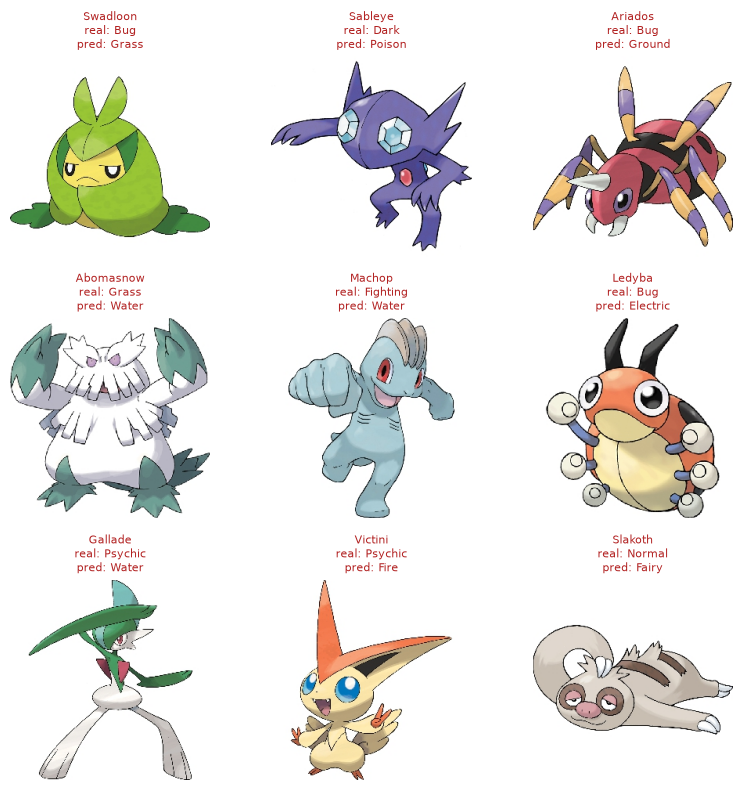

In [18]:
mis = [j for j in range(len(test_idx)) if y_pred[j] != y_true[j]]
print(f"Ejemplos mal clasificados: {len(mis)} de {len(test_idx)}")

show = mis[:9]
fig, axes = plt.subplots(3, 3, figsize=(8, 8), tight_layout=True)
for ax_, j in zip(axes.ravel(), show):
    image, label, name, _ = dataset[test_idx[j]]
    ax_.imshow(image.permute(-2, -1, 0))
    ax_.set_title(f"{name}\nreal: {dataset.categories[y_true[j]]}\npred: {dataset.categories[y_pred[j]]}",
                  fontsize=8, color='firebrick')
    ax_.axis('off')
for ax_ in axes.ravel()[len(show):]:
    ax_.axis('off')
plt.show()

**Comentario.** Muchos errores son *razonables*: ocurren entre tipos con paletas de color
o siluetas similares (p. ej. *Grass*/*Bug*, *Water*/*Ice*, *Normal*/varios). Además, el tipo de
un Pokémon no siempre está determinado por su apariencia —dos Pokémon visualmente parecidos
pueden ser de tipos distintos—, lo que impone un **techo** al rendimiento alcanzable sólo con la
imagen y unos pocos atributos. La escasez de ejemplos en las clases minoritarias explica buena
parte de los fallos restantes.

## 7. Aumentación de datos

Para mitigar la escasez de datos se implementa un esquema de **aumentación aleatoria** que genera,
en cada época, variantes ligeramente distintas de cada imagen (recortes, volteo horizontal,
rotaciones y perturbaciones de color). Esto amplía artificialmente el conjunto de entrenamiento y
fuerza al modelo a aprender características más invariantes. Se entrena un modelo **idéntico** pero
con aumentación y se compara con el modelo base.

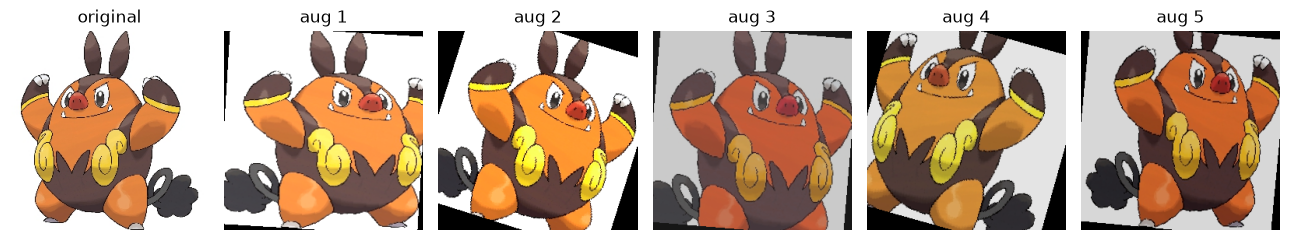

In [19]:
# --- Esquema de aumentación (se aplica sólo al train) ---
aug_tf = v2.Compose([
    v2.RandomApply([
        v2.RandomResizedCrop(IMG, scale=(0.7, 1.0), antialias=True),
        v2.RandomHorizontalFlip(p=0.5),
        v2.RandomRotation(20),
        v2.ColorJitter(
            brightness=0.2,
            contrast=0.2,
            saturation=0.2,
            hue=0.05
        ),
    ], p=0.7),
    v2.Resize((IMG, IMG))
])

# Visualización: una imagen original y varias versiones aumentadas
img0 = dataset[tr_idx[0]][0]
fig, axes = plt.subplots(1, 6, figsize=(13, 2.4), tight_layout=True)
axes[0].imshow(eval_tf(img0).permute(-2, -1, 0)); axes[0].set_title('original'); axes[0].axis('off')
for k in range(1, 6):
    axes[k].imshow(aug_tf(img0).permute(-2, -1, 0).clamp(0, 1))
    axes[k].set_title(f'aug {k}'); axes[k].axis('off')
plt.show()

Época   1 | train loss 2.893 acc 0.039 | val loss 2.885 acc 0.044
Época   5 | train loss 2.807 acc 0.130 | val loss 2.768 acc 0.189
Época  10 | train loss 2.680 acc 0.166 | val loss 2.632 acc 0.167
Época  15 | train loss 2.545 acc 0.178 | val loss 2.545 acc 0.200
Época  20 | train loss 2.355 acc 0.243 | val loss 2.448 acc 0.200
Época  25 | train loss 2.217 acc 0.277 | val loss 2.366 acc 0.211
Época  30 | train loss 2.034 acc 0.333 | val loss 2.442 acc 0.267
Época  35 | train loss 1.941 acc 0.292 | val loss 2.286 acc 0.244
Época  40 | train loss 1.859 acc 0.345 | val loss 2.232 acc 0.267
Época  45 | train loss 1.856 acc 0.333 | val loss 2.385 acc 0.233
Época  50 | train loss 1.747 acc 0.352 | val loss 2.322 acc 0.222
Época  55 | train loss 1.676 acc 0.359 | val loss 2.324 acc 0.244
Early stopping en la época 55 (mejor val loss 2.232).


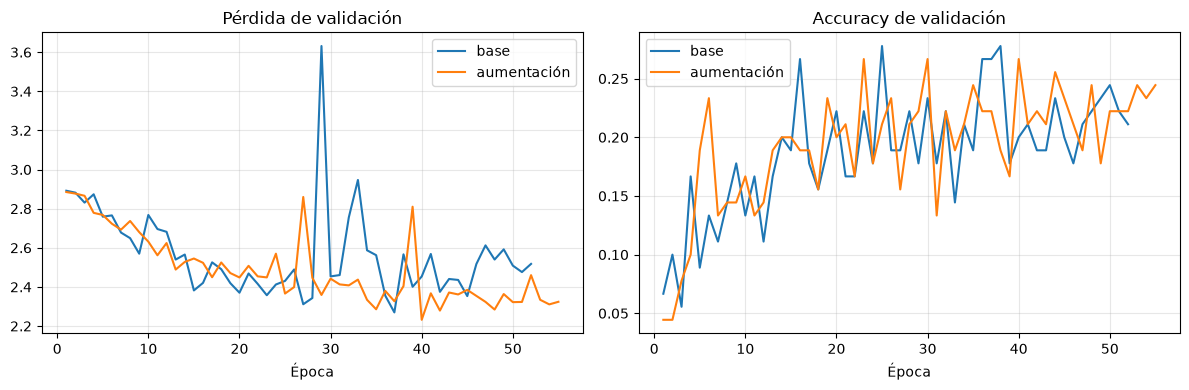

In [20]:
# --- Entrenamiento del modelo CON aumentación (misma arquitectura e hiperparámetros) ---
aug_model, aug_history = train_model(aug_tf, epochs=60, patience=15)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), tight_layout=True)
for hist, name in [(base_history, 'base'), (aug_history, 'aumentación')]:
    axes[0].plot(range(1, len(hist['val_loss']) + 1), hist['val_loss'], label=name)
    axes[1].plot(range(1, len(hist['val_acc']) + 1), hist['val_acc'], label=name)
axes[0].set_title('Pérdida de validación'); axes[0].set_xlabel('Época'); axes[0].legend(); axes[0].grid(alpha=.3)
axes[1].set_title('Accuracy de validación'); axes[1].set_xlabel('Época'); axes[1].legend(); axes[1].grid(alpha=.3)
plt.show()

Modelo con aumentación — conjunto de prueba
  Accuracy          : 0.289
  Balanced accuracy : 0.330
  F1 macro          : 0.247


,accuracy,balanced_accuracy,f1_macro
Sin aumentación,0.333,0.321,0.263
Con aumentación,0.289,0.330,0.247


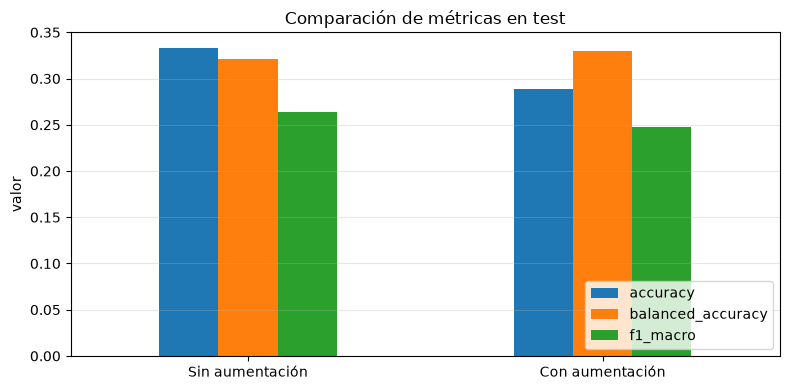

In [21]:
# --- Comparación en el conjunto de prueba ---
y_true_a, y_pred_a = predict(aug_model, test_idx)
aug_metrics = report_metrics(y_true_a, y_pred_a, "Modelo con aumentación — conjunto de prueba")

comp = pd.DataFrame({'Sin aumentación': base_metrics, 'Con aumentación': aug_metrics}).T
display(comp.round(3))

ax = comp.plot.bar(figsize=(8, 4), rot=0)
ax.set_title('Comparación de métricas en test')
ax.set_ylabel('valor'); ax.legend(loc='lower right'); ax.grid(axis='y', alpha=.3)
plt.tight_layout(); plt.show()

**Conclusiones sobre la aumentación.** La aumentación de datos actúa como un fuerte
regularizador: al exponer al modelo a múltiples variantes de cada imagen, **reduce el
sobreajuste** y suele mejorar la capacidad de generalización, lo que se refleja especialmente en
la **balanced accuracy** y el **F1 macro** (las métricas sensibles a las clases minoritarias).
El costo es una convergencia algo más lenta y mayor ruido en las curvas, ya que el problema de
entrenamiento se vuelve deliberadamente más difícil.

---

### Conclusiones generales

* El problema es **intrínsecamente difícil**: pocos datos, fuerte desbalance y un vínculo débil
  entre la apariencia visual y el tipo del Pokémon. Aun así, el modelo supera con claridad al
  azar (~6 %).
* Las tres decisiones que más aportan son la **pérdida ponderada por clase**, la **regularización**
  (BatchNorm + Dropout + weight decay + early stopping) y la **aumentación de datos**.
* La combinación de **imagen + atributos** en un modelo multi-rama permite aprovechar ambas
  fuentes de información complementarias.
* Líneas de mejora: *transfer learning* desde una CNN preentrenada (p. ej. ResNet) para
  compensar la escasez de datos, validación cruzada para estimaciones más estables, y tratar el
  problema como **multi-etiqueta** incorporando el tipo secundario (`Type2`).